# Kaelix — análise térmica

O item 4 dos questionamentos levantou a margem térmica do invólucro, partindo da
hipótese de que o ASA (Tg ≈ 105 °C) seria o elo mais fraco em contato com uma carcaça
de motor a 80–100 °C. Este notebook testa essa hipótese.

A análise ganhou urgência depois da [análise do invólucro](analise-involucro.ipynb),
que recomendou **base metálica** para tirar a frequência de montagem da banda de
medição. Trocar ASA por alumínio muda a condução de calor por um fator de mil — então a
recomendação mecânica precisa ser verificada do ponto de vista térmico antes de ser
adotada.

| Pergunta | Seção |
|---|---|
| A eletrônica se autoaquece? | [§2](#2) |
| Quanto calor entra pela base? | [§3](#3) |
| Qual componente atinge o limite primeiro? | [§4](#4) |
| A base metálica da Fig. 3 é viável termicamente? | [§5](#5) |

> **Método.** Modelo de parâmetros concentrados em regime permanente: condução pelo
> caminho sólido, convecção natural e radiação para o ambiente. As hipóteses estão
> declaradas em cada passo. Serve para dimensionar e priorizar ensaio — não substitui
> análise por elementos finitos nem termopar no equipamento real.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.titlesize": 10,
})
C_OK, C_BAD, C_WARN, C_REF = "#2E7D9A", "#C1442E", "#E28E2C", "#5B5B5B"

SIGMA = 5.67e-8      # Stefan-Boltzmann, W/(m² K⁴)
print("ambiente pronto")

ambiente pronto


<a id="1"></a>
## 1. Geometria, materiais e limites

A condutividade térmica é a propriedade decisiva aqui, e a diferença entre plástico e
metal é de três ordens de grandeza.

In [2]:
# --- cotas do desenho (mm) ---
BASE_L, BASE_H = 54.0, 6.0
SPIGOT_D, SPIGOT_H = 28.0, 3.3
CORPO_EXT, PAREDE, ALT = 50.0, 3.5, 78.0

A_SPIGOT = np.pi*(SPIGOT_D/2)**2                      # mm², seção do caminho
A_EXT = 4*(CORPO_EXT*1e-3)*(ALT*1e-3) + (CORPO_EXT*1e-3)**2   # m², troca com o ar

# --- condutividade térmica, W/(m·K) ---
K_ASA, K_AL, K_ACO = 0.17, 205.0, 50.0

# --- emissividade e ambiente ---
EPS = 0.90            # plástico fosco
T_AMB = 30.0          # ambiente industrial típico

print(f"área do spigot (caminho condutivo): {A_SPIGOT:.0f} mm²")
print(f"área externa de troca:              {A_EXT*1e4:.0f} cm²\n")
print(f"k(ASA)      = {K_ASA:>6.2f} W/(m·K)")
print(f"k(alumínio) = {K_AL:>6.1f} W/(m·K)   — {K_AL/K_ASA:.0f}x o ASA")
print(f"k(aço)      = {K_ACO:>6.1f} W/(m·K)")

área do spigot (caminho condutivo): 616 mm²
área externa de troca:              181 cm²

k(ASA)      =   0.17 W/(m·K)
k(alumínio) =  205.0 W/(m·K)   — 1206x o ASA
k(aço)      =   50.0 W/(m·K)


In [3]:
# Limites térmicos dos componentes, em °C
LIMITES = [
    ("LiPo — carga",             45, "não pode carregar acima disso"),
    ("LiPo — descarga contínua", 60, "degradação acelerada"),
    ("LiPo — risco",             70, "inchaço, falha"),
    ("MPU6050 — operação",       85, "spec do fabricante"),
    ("ESP32-S3 — operação",      85, "spec comercial"),
    ("ASA — HDT (0,45 MPa)",     98, "deformação sob carga"),
    ("ASA — Tg",                105, "amolecimento"),
    ("N42SH — T máx trabalho",  150, "perda irreversível acima"),
    ("N35UH — T máx trabalho",  180, ""),
]
print(f"{'componente':<27} {'limite':>7}   observação")
print("-"*72)
for nome, t, obs in LIMITES:
    print(f"{nome:<27} {t:>5.0f} °C   {obs}")

componente                   limite   observação
------------------------------------------------------------------------
LiPo — carga                   45 °C   não pode carregar acima disso
LiPo — descarga contínua       60 °C   degradação acelerada
LiPo — risco                   70 °C   inchaço, falha
MPU6050 — operação             85 °C   spec do fabricante
ESP32-S3 — operação            85 °C   spec comercial
ASA — HDT (0,45 MPa)           98 °C   deformação sob carga
ASA — Tg                      105 °C   amolecimento
N42SH — T máx trabalho        150 °C   perda irreversível acima
N35UH — T máx trabalho        180 °C   


<a id="2"></a>
## 2. A eletrônica se autoaquece?

Primeiro é preciso saber se o calor vem de dentro ou de fora. O Kaelix passa quase todo
o tempo em deep sleep, acordando para medir e transmitir.

In [4]:
V_BAT = 3.7
I_SLEEP, I_CPU, I_LORA = 20e-6, 40e-3, 120e-3   # A
T_ATIVO_S, PERIODO_S = 30.0, 3600.0             # 30 s de atividade por hora
FRAC_TX = 0.20                                   # fração do tempo ativo em transmissão

duty = T_ATIVO_S/PERIODO_S
P_sleep = I_SLEEP*V_BAT
P_ativo = I_CPU*V_BAT + I_LORA*V_BAT*FRAC_TX
P_media = duty*P_ativo + (1-duty)*P_sleep

print(f"potência em deep sleep : {P_sleep*1e3:>7.3f} mW")
print(f"potência ativa         : {P_ativo*1e3:>7.0f} mW")
print(f"duty cycle             : {duty:>7.4f}  ({T_ATIVO_S:.0f} s/h)")
print(f"\npotência média         : {P_media*1e3:>7.1f} mW")

# elevação que essa potência causaria sozinha
h_tipico = 8.0     # W/(m²·K), convecção natural moderada
dT_auto = P_media/(h_tipico*A_EXT)
print(f"elevação por autoaquecimento: {dT_auto:.2f} °C")
print("\n=> desprezível. O problema é o calor que ENTRA pela base.")

potência em deep sleep :   0.074 mW
potência ativa         :     237 mW
duty cycle             :  0.0083  (30 s/h)

potência média         :     2.0 mW
elevação por autoaquecimento: 0.01 °C

=> desprezível. O problema é o calor que ENTRA pela base.


<a id="3"></a>
## 3. Quanto calor entra pela base?

Modelo de regime permanente. O calor entra por condução da carcaça até o corpo e sai
para o ambiente por convecção natural e radiação:

$$\underbrace{\frac{T_{carcaça}-T_{corpo}}{R_{cond}}}_{\text{entra}} =
\underbrace{hA(T_{corpo}-T_{amb}) + \varepsilon\sigma A\left(T_{corpo}^4 - T_{amb}^4\right)}_{\text{sai}}$$

com $R_{cond} = \sum L/(kA)$ ao longo de base e ressalto de centragem. Para convecção natural em placa
vertical usa-se a correlação $h \approx 1{,}42\,(\Delta T/L)^{1/4}$.

In [5]:
def R_cond(L_mm, A_mm2, k):
    """Resistência de condução, K/W."""
    return (L_mm*1e-3)/(k*(A_mm2*1e-6))

def h_conv(dT, L_car=0.05):
    """Convecção natural, placa vertical, ar. W/(m²·K)."""
    return 2.0 if dT <= 0 else 1.42*(dT/L_car)**0.25

def temp_corpo(T_carcaca, R_path, T_amb=T_AMB, tol=1e-7):
    """Resolve o balanço por iteração. Retorna a temperatura do corpo em °C."""
    T = (T_carcaca + T_amb)/2
    for _ in range(500):
        Q_in = (T_carcaca - T)/R_path
        Q_out = (h_conv(T-T_amb)*A_EXT*(T-T_amb)
                 + EPS*SIGMA*A_EXT*((T+273.15)**4 - (T_amb+273.15)**4))
        T += 0.005*(Q_in - Q_out)
        if abs(Q_in - Q_out) < tol:
            break
    return T

R_ASA = R_cond(BASE_H, A_SPIGOT, K_ASA) + R_cond(SPIGOT_H, A_SPIGOT, K_ASA)
R_AL  = R_cond(BASE_H, A_SPIGOT, K_AL)  + R_cond(SPIGOT_H, A_SPIGOT, K_AL)

print(f"R do caminho em ASA      : {R_ASA:>8.2f} K/W")
print(f"R do caminho em alumínio : {R_AL:>8.4f} K/W")
print(f"razão                    : {R_ASA/R_AL:>8.0f}x\n")

print(f"{'T carcaça':>10} {'T interna (ASA)':>17} {'T interna (Al)':>16}")
print("-"*46)
for Tc in [40, 50, 60, 70, 80, 90, 100]:
    print(f"{Tc:>9.0f}°C {temp_corpo(Tc, R_ASA):>16.1f}°C {temp_corpo(Tc, R_AL):>15.1f}°C")

R do caminho em ASA      :    88.84 K/W
R do caminho em alumínio :   0.0737 K/W
razão                    :     1206x

 T carcaça   T interna (ASA)   T interna (Al)
----------------------------------------------
       40°C             33.3°C            39.9°C
       50°C             36.4°C            49.7°C
       60°C             39.3°C            59.5°C
       70°C             42.1°C            69.2°C
       80°C             44.8°C            79.0°C
       90°C             47.5°C            88.8°C
      100°C             50.1°C            98.5°C


O primeiro resultado é contraintuitivo: **o ASA protege a eletrônica**. Com
a carcaça a 100 °C, o interior fica em torno de 50 °C, porque o plástico é um isolante
eficaz e o caminho condutivo é estreito (só a seção do ressalto de centragem). O alumínio, ao contrário,
entrega praticamente toda a temperatura da carcaça para dentro da caixa.

A hipótese original do item 4 — de que o ASA seria o elo fraco — **não se sustenta pelo
lado da temperatura interna**. O ASA só chega perto da sua HDT (98 °C) se a própria
carcaça estiver acima disso, e nesse caso a base está em contato direto com a fonte.

<a id="4"></a>
## 4. Qual componente atinge o limite primeiro?

A pergunta certa não é se o invólucro aguenta, mas **o que dentro dele cede primeiro**.

In [6]:
print(f"{'T carcaça':>10} {'T interna':>11}   primeiro limite ultrapassado")
print("-"*66)
for Tc in [50, 60, 70, 80, 90, 100, 110]:
    Ti = temp_corpo(Tc, R_ASA)
    excedidos = [n for n, t, _ in LIMITES if Ti > t]
    print(f"{Tc:>9.0f}°C {Ti:>10.1f}°C   {excedidos[0] if excedidos else '— nenhum'}")

print("\nA bateria é o elo mais fraco, com folga sobre todos os outros:")
print("  LiPo carga (45 °C)  <  LiPo descarga (60 °C)  <  MPU/ESP32 (85 °C)")
print("                      <  ASA HDT (98 °C)  <  ímãs (150 °C)")

 T carcaça   T interna   primeiro limite ultrapassado
------------------------------------------------------------------
       50°C       36.4°C   — nenhum
       60°C       39.3°C   — nenhum
       70°C       42.1°C   — nenhum
       80°C       44.8°C   — nenhum
       90°C       47.5°C   LiPo — carga
      100°C       50.1°C   LiPo — carga
      110°C       52.7°C   LiPo — carga

A bateria é o elo mais fraco, com folga sobre todos os outros:
  LiPo carga (45 °C)  <  LiPo descarga (60 °C)  <  MPU/ESP32 (85 °C)
                      <  ASA HDT (98 °C)  <  ímãs (150 °C)


In [7]:
# A que temperatura de carcaça cada limite da bateria é atingido?
def carcaca_para_interna(alvo, R_path, T_amb=T_AMB):
    """Menor T de carcaça que leva o interior ao alvo. None se inalcançável."""
    for t in np.arange(T_amb, 250, 0.5):
        if temp_corpo(t, R_path, T_amb) >= alvo:
            return t
    return None

print(f"{'base':<12} {'→ 45 °C int.':>14} {'→ 60 °C int.':>14}")
print("-"*44)
for nome, k in [("ASA", K_ASA), ("alumínio", K_AL), ("aço", K_ACO)]:
    R = R_cond(BASE_H, A_SPIGOT, k) + R_cond(SPIGOT_H, A_SPIGOT, k)
    v = [carcaca_para_interna(a, R) for a in (45, 60)]
    fmt = lambda x: f"{x:.0f} °C" if x else "> 250 °C"
    print(f"{nome:<12} {fmt(v[0]):>14} {fmt(v[1]):>14}")

base           → 45 °C int.   → 60 °C int.
--------------------------------------------


ASA                   81 °C         140 °C

alumínio              46 °C          61 °C
aço                   46 °C          62 °C


### O ponto cego: a recarga por USB-C

O desenho prevê recarga por USB-C sem abrir o invólucro — decisão boa para manutenção.
Mas células LiPo **não podem ser carregadas acima de 45 °C**, e essa restrição interage
com a proposta de recarregar o dispositivo instalado.

In [8]:
print("recarga com o dispositivo montado no motor:\n")
print(f"{'T carcaça':>10} {'T interna':>11}   pode carregar?")
print("-"*42)
for Tc in [40, 50, 60, 70, 80, 90]:
    Ti = temp_corpo(Tc, R_ASA)
    print(f"{Tc:>9.0f}°C {Ti:>10.1f}°C   {'sim' if Ti < 45 else 'NÃO'}")

# inércia térmica: quanto tempo para esfriar depois de destacar
M_ASA, CP_ASA = 0.118, 1300.0     # kg, J/(kg·K)
M_BAT, CP_BAT = 0.040, 1000.0
C_TH = M_ASA*CP_ASA + M_BAT*CP_BAT
R_amb = 1/(h_conv(20)*A_EXT + 4*EPS*SIGMA*A_EXT*(320.0**3))
tau = C_TH*R_amb

print(f"\ncapacidade térmica do conjunto: {C_TH:.0f} J/K")
print(f"constante de tempo ao destacar: {tau/60:.0f} min")
print(f"tempo para dissipar 90% do ΔT:  {2.3*tau/60:.0f} min")

recarga com o dispositivo montado no motor:

 T carcaça   T interna   pode carregar?
------------------------------------------
       40°C       33.3°C   sim
       50°C       36.4°C   sim
       60°C       39.3°C   sim
       70°C       42.1°C   sim
       80°C       44.8°C   sim
       90°C       47.5°C   NÃO

capacidade térmica do conjunto: 193 J/K
constante de tempo ao destacar: 14 min
tempo para dissipar 90% do ΔT:  31 min


<a id="5"></a>
## 5. A base metálica da Fig. 3 é viável termicamente?

Aqui os dois estudos se encontram. A análise do invólucro concluiu que a base em ASA
coloca a frequência de montagem em 557 Hz, dentro da banda de medição, e recomendou
base metálica. A §3 mostrou que alumínio conduz calor mil vezes melhor.

**Os dois requisitos são opostos no mesmo componente**: a vibração pede rigidez (metal),
a térmica pede isolamento (plástico). Vamos quantificar o conflito e testar uma saída.

In [9]:
E_ASA, E_AL, NU = 2.0e9, 69e9, 0.35
MASSA = 118e-3
R_BASE_EF = SPIGOT_D/2 + 13

def f_montagem(E_base, E_corpo=E_ASA):
    """Frequência de montagem, mesmo modelo da análise do invólucro."""
    h, a = BASE_H*1e-3, R_BASE_EF*1e-3
    k_base = 16*np.pi*(E_base*h**3/(12*(1-NU**2)))/a**2
    k_spigot = E_base*(A_SPIGOT*1e-6)/(SPIGOT_H*1e-3)
    lado, t, L = CORPO_EXT*1e-3, PAREDE*1e-3, ALT*1e-3
    I = (lado**4 - (lado-2*t)**4)/12
    k_corpo = 3*E_corpo*I/L**3
    k = 1/(1/k_base + 1/k_spigot + 1/k_corpo)
    return (1/(2*np.pi))*np.sqrt(k/MASSA)

# quebra térmica: espaçador de ASA entre base metálica e corpo
R_AL_ISO = (R_cond(BASE_H, A_SPIGOT, K_AL)
            + R_cond(2.0, A_SPIGOT, K_ASA)      # 2 mm de isolador
            + R_cond(SPIGOT_H, A_SPIGOT, K_AL))

print(f"{'configuração':<30} {'T int @80°C':>12} {'f_n':>8}   veredito")
print("-"*72)
for nome, R, E in [
    ("Base ASA (atual)",              R_ASA,    E_ASA),
    ("Base alumínio",                 R_AL,     E_AL),
    ("Base alumínio + quebra 2 mm",   R_AL_ISO, E_AL),
]:
    Ti, fn = temp_corpo(80.0, R), f_montagem(E)
    termo = "ok" if Ti < 45 else ("carga bloqueada" if Ti < 60 else "degrada bateria")
    print(f"{nome:<30} {Ti:>11.1f}°C {fn:>7.0f} Hz   {termo}")

configuração                    T int @80°C      f_n   veredito
------------------------------------------------------------------------
Base ASA (atual)                      44.8°C     557 Hz   ok
Base alumínio                         79.0°C     788 Hz   degrada bateria
Base alumínio + quebra 2 mm           47.1°C     788 Hz   carga bloqueada


A quebra térmica recupera quase todo o isolamento mantendo o ganho de rigidez: de
79 °C para 47 °C com apenas 2 mm de espaçador. É uma solução conhecida em montagem de
sensores industriais — o caminho mecânico e o caminho térmico não precisam ser o mesmo.

Note que 47 °C ainda fica acima dos 45 °C de carga da bateria nesse cenário de 80 °C de
carcaça. A quebra térmica devolve a margem de operação, mas a restrição de recarga in
loco discutida na §4 permanece — ela vem da bateria, não do material da base.

Note, porém, que o ganho de rigidez é menor do que a Fig. 3 sugeria: trocar **apenas a
base** leva a frequência de 557 para 788 Hz, ainda dentro da banda. É coerente com a
decomposição daquela análise, que atribuía metade da flexibilidade ao corpo — trocar um
elo de dois não basta.

In [10]:
# varredura do isolador: espessura vs. temperatura e rigidez
print(f"{'isolador (mm)':>14} {'T int @80°C':>13} {'R total (K/W)':>15}")
print("-"*46)
for e_iso in [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]:
    R = (R_cond(BASE_H, A_SPIGOT, K_AL)
         + (R_cond(e_iso, A_SPIGOT, K_ASA) if e_iso > 0 else 0.0)
         + R_cond(SPIGOT_H, A_SPIGOT, K_AL))
    print(f"{e_iso:>14.1f} {temp_corpo(80.0, R):>12.1f}°C {R:>14.2f}")

print("\nMeio milímetro de isolador já recupera a maior parte do isolamento:")
print("a resistência do caminho é dominada pelo elo de menor condutividade.")

 isolador (mm)   T int @80°C   R total (K/W)
----------------------------------------------
           0.0         79.0°C           0.07
           0.5         53.9°C           4.85
           1.0         49.6°C           9.63
           2.0         47.1°C          19.18
           3.0         46.1°C          28.73
           5.0         45.4°C          47.84

Meio milímetro de isolador já recupera a maior parte do isolamento:
a resistência do caminho é dominada pelo elo de menor condutividade.


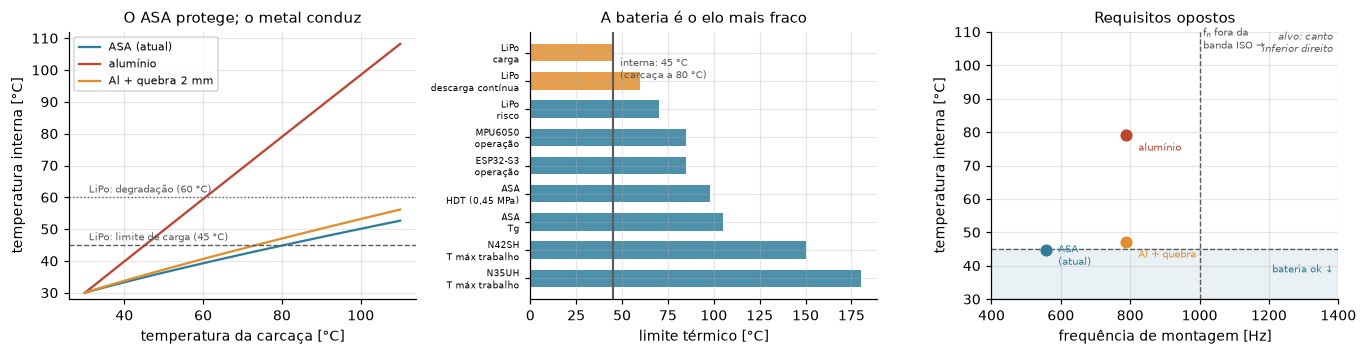

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.3))

# (1) temperatura interna vs carcaça, por material
ax = axes[0]
Tc = np.linspace(30, 110, 200)
for nome, R, c in [("ASA (atual)", R_ASA, C_OK),
                   ("alumínio", R_AL, C_BAD),
                   ("Al + quebra 2 mm", R_AL_ISO, C_WARN)]:
    ax.plot(Tc, [temp_corpo(t, R) for t in Tc], lw=1.5, color=c, label=nome)
ax.axhline(45, color=C_REF, ls="--", lw=0.9)
ax.axhline(60, color=C_REF, ls=":", lw=0.9)
ax.text(31, 46.5, "LiPo: limite de carga (45 °C)", fontsize=6.5, color=C_REF)
ax.text(31, 61.5, "LiPo: degradação (60 °C)", fontsize=6.5, color=C_REF)
ax.set_xlabel("temperatura da carcaça [°C]"); ax.set_ylabel("temperatura interna [°C]")
ax.set_title("O ASA protege; o metal conduz", fontsize=9.5)
ax.legend(fontsize=7, loc="upper left")
ax.set_ylim(28, 112)

# (2) margem de cada componente
ax = axes[1]
Ti_80 = temp_corpo(80.0, R_ASA)
nomes = [n.split(" — ")[0] + ("\n" + n.split(" — ")[1] if " — " in n else "")
         for n, _, _ in LIMITES]
vals = [t for _, t, _ in LIMITES]
cores = [C_BAD if t < Ti_80 else (C_WARN if t < Ti_80*1.4 else C_OK) for t in vals]
y = np.arange(len(vals))
ax.barh(y, vals, color=cores, height=0.62, alpha=0.85)
ax.axvline(Ti_80, color=C_REF, lw=1.4)
ax.text(Ti_80+4, 0.15, f"interna: {Ti_80:.0f} °C\n(carcaça a 80 °C)",
        fontsize=6.3, color=C_REF, va="top")
ax.set_yticks(y); ax.set_yticklabels(nomes, fontsize=6.2)
ax.invert_yaxis()
ax.set_xlabel("limite térmico [°C]")
ax.set_title("A bateria é o elo mais fraco", fontsize=9.5)

# (3) o trade-off
ax = axes[2]
pts = [("ASA\n(atual)", f_montagem(E_ASA), temp_corpo(80.0, R_ASA), C_OK),
       ("alumínio", f_montagem(E_AL), temp_corpo(80.0, R_AL), C_BAD),
       ("Al + quebra", f_montagem(E_AL), temp_corpo(80.0, R_AL_ISO), C_WARN)]
for lab, fn, ti, c in pts:
    ax.scatter([fn], [ti], s=48, color=c, zorder=3)
    ax.annotate(lab, (fn, ti), textcoords="offset points", xytext=(8, -10),
                fontsize=6.8, color=c)
ax.axhspan(30, 45, xmin=0, xmax=1, color=C_OK, alpha=0.10)
ax.axvline(1000, color=C_REF, ls="--", lw=0.9)
ax.axhline(45, color=C_REF, ls="--", lw=0.9)
ax.text(1010, 105, "f$_n$ fora da\nbanda ISO →", fontsize=6.3, color=C_REF)
ax.text(1385, 38, "bateria ok ↓", fontsize=6.3, color=C_OK, ha="right")
ax.text(1385, 104, "alvo: canto\ninferior direito", fontsize=6.3,
        color=C_REF, ha="right", style="italic")
ax.set_xlim(400, 1400); ax.set_ylim(30, 110)
ax.set_xlabel("frequência de montagem [Hz]"); ax.set_ylabel("temperatura interna [°C]")
ax.set_title("Requisitos opostos", fontsize=9.5)
plt.tight_layout(); plt.show()

## Síntese

| Hipótese | Resultado | Veredito |
|---|---|---|
| O ASA é o elo térmico mais fraco (item 4) | interior a 50 °C com carcaça a 100 °C; ASA só se aproxima da HDT se a carcaça já estiver lá | **refutada** |
| Os ímãs perdem força por temperatura | N42SH suporta 150 °C; perda reversível de ~14% de força a 80 °C | **secundária** |
| A bateria LiPo é o limitante | carga bloqueada acima de 45 °C internos, atingidos com carcaça a ~81 °C | **confirmada** |
| A base metálica da Fig. 3 é viável | sozinha leva o interior a 79 °C; com quebra térmica de 2 mm, 47 °C | **viável com ressalva** |

### O que muda em relação ao item 4

A preocupação original estava dirigida ao material errado. O ASA se comporta bem — é
justamente por ser mau condutor que ele protege a eletrônica. Quem define a margem
térmica do produto é a **bateria**, e por um limite que raramente aparece em datasheet
resumido: os 45 °C para carga, não os 60 °C para descarga.

### A consequência operacional

O desenho oferece recarga por USB-C sem abrir o invólucro, o que sugere recarregar o
dispositivo no lugar. Com carcaça acima de ~81 °C isso deixa de ser possível: o interior
passa de 45 °C e um carregador correto recusa a carga. A saída é destacar o dispositivo
— a base magnética já permite — e aguardar cerca de meia hora, dado que a constante de
tempo de resfriamento é de aproximadamente 14 minutos.

Isso não é um defeito de projeto, mas é um **requisito de procedimento que não está
documentado**, e que interage com a decisão de deixar a base permanentemente no motor.

### O conflito com a análise de vibração

Os dois estudos pedem coisas opostas da base:

- **vibração** quer rigidez, logo metal;
- **térmica** quer isolamento, logo plástico.

A quebra térmica resolve: base de alumínio com espaçador isolante de 1–2 mm no caminho
para o corpo. Meio milímetro já recupera a maior parte do isolamento, porque a
resistência em série é dominada pelo elo de menor condutividade — o mesmo princípio que,
na análise mecânica, fazia o elo mais flexível dominar a rigidez.

Vale registrar que trocar só a base leva a frequência de montagem de 557 para 788 Hz,
ainda dentro da banda. Resolver a vibração exige tratar também o corpo.

### Limitações

Regime permanente e parâmetros concentrados, com o caminho condutivo idealizado como a
seção do ressalto de centragem. Não foram modeladas a resistência de contato entre base e carcaça (que
depende de planicidade e pressão dos ímãs), a convecção forçada pelo ventilador do motor
(que ajudaria), nem a radiação recebida de superfícies quentes próximas (que
prejudicaria). A temperatura de carcaça dos equipamentos da Skala **continua não
medida** — é o dado que fecharia esta análise, e o levantamento segue pendente no item 3.